# Xarray-Spatial Diffusion: Scalar field spreading

Heat, moisture, and contaminants all spread through space over time. The `diffuse()` function solves the 2D diffusion equation on a raster, stepping a scalar field forward with an explicit finite-difference scheme. It handles uniform and spatially varying diffusivity, four boundary modes, and runs on all four xrspatial backends.

### What you'll build

1. Spread a point source across a grid and watch the field evolve
2. Compare four boundary modes side by side
3. Block heat flow with a spatially varying diffusivity wall
4. Simulate heat spreading through a building floor plan after an HVAC failure

![Diffusion preview](images/diffusion_hvac_preview.png)

[Point source diffusion](#Point-source-diffusion) · [Boundary modes](#Boundary-modes) · [Spatially varying diffusivity](#Spatially-varying-diffusivity) · [HVAC failure simulation](#HVAC-failure-simulation)

Standard imports plus the `diffuse` function from `xrspatial.diffusion`.

In [1]:
import numpy as np
import xarray as xr

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from xrspatial.diffusion import diffuse

## Point source diffusion

The simplest test case: a single hot cell in the center of a cold field. The [diffusion equation](https://en.wikipedia.org/wiki/Diffusion_equation) spreads that energy outward in a Gaussian pattern. Running more steps lets the heat spread further and the peak temperature drop.

Four panels show the field at steps 0, 10, 50, and 200.

/tmp/ipykernel_68716/1643375946.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


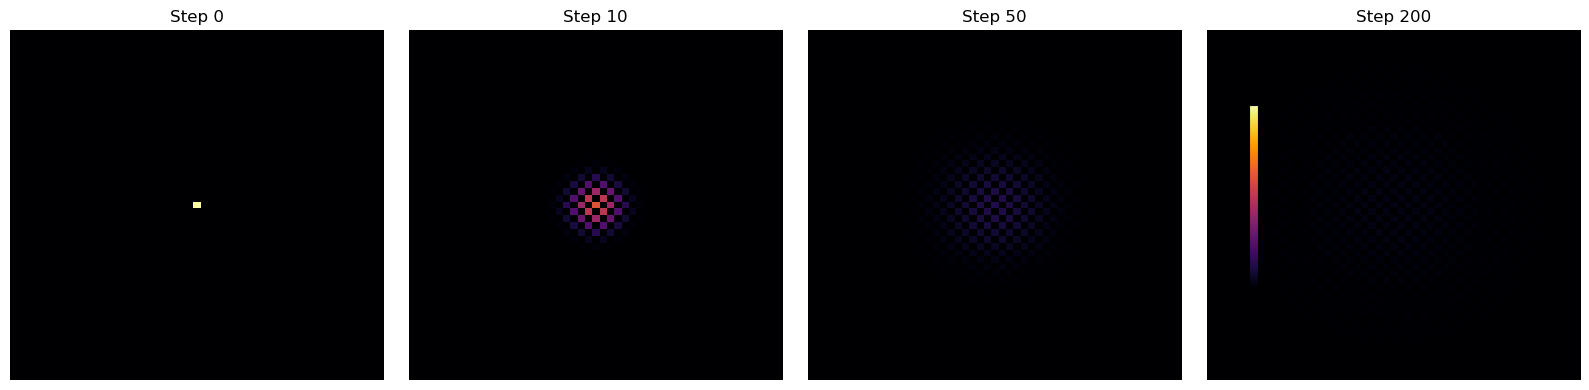

In [2]:
# 51x51 grid with a point source at the center
shape = (51, 51)
data = np.zeros(shape)
data[25, 25] = 100.0

initial = xr.DataArray(data, dims=['y', 'x'], attrs={'res': (1.0, 1.0)})

steps_list = [0, 10, 50, 200]
results = {}
for s in steps_list:
    if s == 0:
        results[s] = initial
    else:
        results[s] = diffuse(initial, diffusivity=1.0, steps=s, boundary='nearest')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, s in zip(axes, steps_list):
    results[s].plot.imshow(ax=ax, cmap='inferno', vmin=0, vmax=10,
                           add_colorbar=False)
    ax.set_title(f'Step {s}', fontsize=12)
    ax.set_axis_off()
fig.colorbar(axes[-1].images[-1], ax=axes, shrink=0.6, label='Temperature')
plt.tight_layout()

At step 0 all the energy sits in one cell. By step 200 it has spread into a broad, low mound. Total heat is conserved with `boundary='nearest'`, just redistributed across the grid.

## Boundary modes

The `boundary` parameter controls what happens when the stencil reaches the edge of the raster. Four options are available:

- **`'nan'`**: pad with NaN, so edges decay to NaN over time
- **`'nearest'`**: repeat edge values, conserving energy
- **`'reflect'`**: mirror the interior, simulating a symmetric boundary
- **`'wrap'`**: connect opposite edges, making the domain periodic

A hot cell placed near the top edge makes the differences obvious. Each panel shows the same source after 30 diffusion steps.

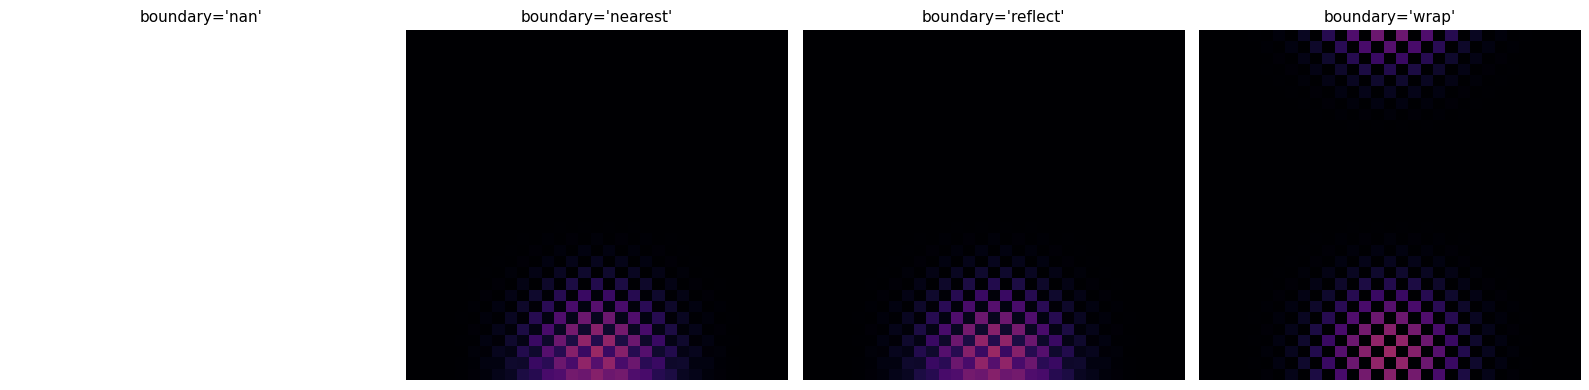

In [3]:
# Hot spot near the top edge
data_edge = np.zeros((31, 31))
data_edge[2, 15] = 100.0

edge_field = xr.DataArray(data_edge, dims=['y', 'x'], attrs={'res': (1.0, 1.0)})

boundaries = ['nan', 'nearest', 'reflect', 'wrap']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, bnd in zip(axes, boundaries):
    r = diffuse(edge_field, diffusivity=1.0, steps=30, boundary=bnd)
    r.plot.imshow(ax=ax, cmap='inferno', vmin=0, vmax=5, add_colorbar=False)
    ax.set_title(f"boundary='{bnd}'", fontsize=11)
    ax.set_axis_off()
plt.tight_layout()

<div class="alert alert-block alert-warning">
<b>Boundary choice affects conservation.</b> With <code>boundary='nan'</code>, heat that reaches the edge disappears. If you need total energy to stay constant (mass balance, pollutant budgets), use <code>'nearest'</code> or <code>'reflect'</code> instead.
</div>

## Spatially varying diffusivity

Passing a DataArray for the `diffusivity` parameter lets you model materials with different thermal properties. A region of low diffusivity acts as an insulating wall that slows heat transfer.

Below, a vertical strip of near-zero diffusivity (0.01) splits the grid in half. A heat source on the left side runs for 300 steps. The left panel shows the diffusivity field and the right panel shows the resulting temperature.

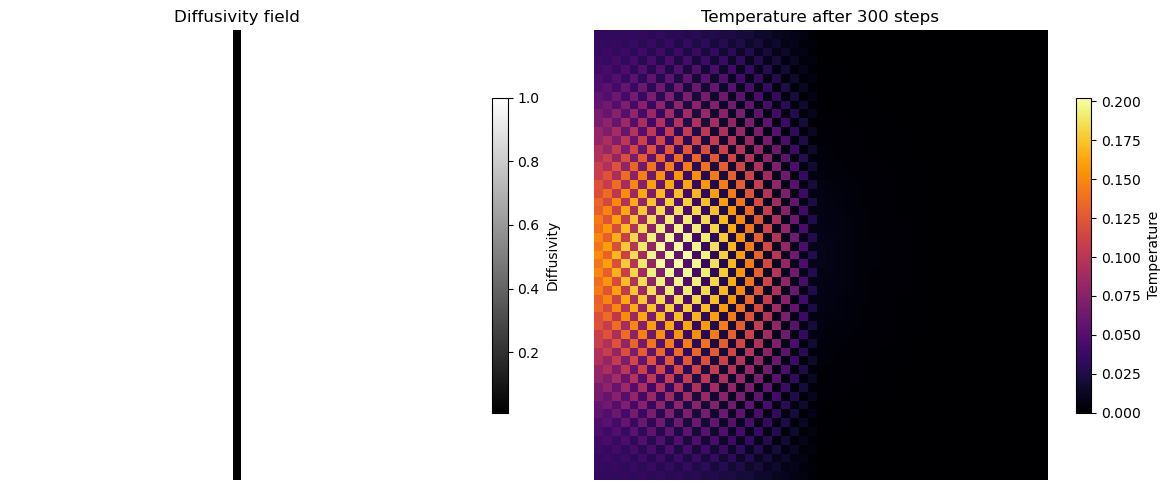

In [4]:
shape = (51, 51)
data = np.zeros(shape)
data[25, 10] = 100.0  # heat source on the left side

# Diffusivity: uniform 1.0 except a thin vertical wall
alpha = np.ones(shape)
alpha[:, 25] = 0.01

field = xr.DataArray(data, dims=['y', 'x'], attrs={'res': (1.0, 1.0)})
alpha_da = xr.DataArray(alpha, dims=['y', 'x'], attrs={'res': (1.0, 1.0)})

result = diffuse(field, diffusivity=alpha_da, steps=300, boundary='nearest')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

alpha_da.plot.imshow(ax=axes[0], cmap='gray', add_colorbar=True,
                     cbar_kwargs={'label': 'Diffusivity', 'shrink': 0.7})
axes[0].set_title('Diffusivity field', fontsize=12)
axes[0].set_axis_off()

result.plot.imshow(ax=axes[1], cmap='inferno', vmin=0, add_colorbar=True,
                   cbar_kwargs={'label': 'Temperature', 'shrink': 0.7})
axes[1].set_title('Temperature after 300 steps', fontsize=12)
axes[1].set_axis_off()

plt.tight_layout()

Most of the heat stays on the left side. The wall does not block transfer completely (diffusivity is 0.01, not zero), so a small amount leaks through. Setting a column to NaN would create a true barrier instead.

## HVAC failure simulation

A more practical scenario: a building floor plan where a cooling unit fails. The room starts at a comfortable 22 °C. A 5x5 block representing the failed zone jumps to 35 °C. Walls are marked with NaN (impassable), with a door opening along the top wall that lets heat escape into the corridor.

Four snapshots show how the hot zone spreads through the room and bleeds out the doorway.

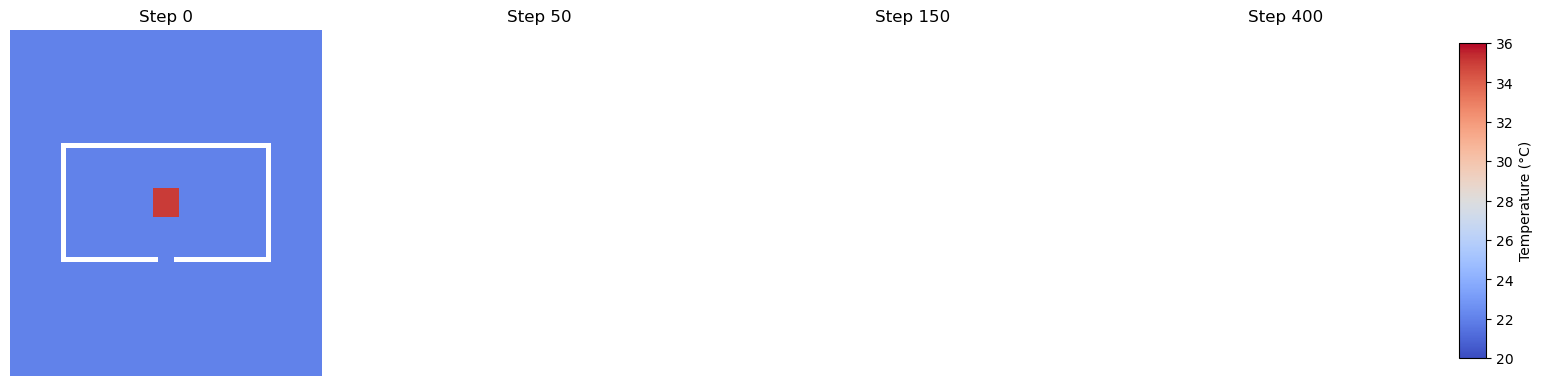

In [5]:
shape = (61, 61)
temp = np.full(shape, 22.0)

# Failed zone: 5x5 block near center
temp[28:33, 28:33] = 35.0

# Walls (NaN = impassable)
temp[20, 10:50] = np.nan
temp[40, 10:50] = np.nan
temp[20:41, 10] = np.nan
temp[20:41, 50] = np.nan

# Door opening in the top wall
temp[20, 29:32] = 22.0

floor_plan = xr.DataArray(temp, dims=['y', 'x'], attrs={'res': (1.0, 1.0)})

snapshots = [0, 50, 150, 400]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, s in zip(axes, snapshots):
    if s == 0:
        r = floor_plan
    else:
        r = diffuse(floor_plan, diffusivity=0.5, steps=s, boundary='nearest')
    im = r.plot.imshow(ax=ax, cmap='coolwarm', vmin=20, vmax=36, add_colorbar=False)
    ax.set_title(f'Step {s}', fontsize=12)
    ax.set_axis_off()
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Temperature (\u00b0C)')
fig.savefig('images/diffusion_hvac_preview.png', bbox_inches='tight', dpi=120)

By step 400 the hot zone has warmed most of the enclosed room, and a plume of heat is leaking through the doorway. NaN walls block diffusion entirely, so the only path out is through the opening.

<div class="alert alert-block alert-warning">
<b>Time step stability.</b> The explicit forward-Euler scheme is conditionally stable. When you omit <code>dt</code>, the solver picks the largest stable step automatically (<code>dt = 0.25 * dx^2 / max(alpha)</code>). If you set <code>dt</code> manually and make it too large, the solution will oscillate and blow up. Stick with the auto value unless you have a specific reason to override it.
</div>

### References

- [Diffusion equation](https://en.wikipedia.org/wiki/Diffusion_equation), Wikipedia
- [Forward Euler method](https://en.wikipedia.org/wiki/Euler_method), Wikipedia
- [Finite difference method for heat equation](https://en.wikipedia.org/wiki/Finite_difference_method#Example:_The_heat_equation), Wikipedia
- [CFL stability condition](https://en.wikipedia.org/wiki/Courant%E2%80%93Friedrichs%E2%80%93Lewy_condition), Wikipedia